## Baseline Regression Modeling
### Steel Industry Energy Consumption Dataset

**Objective:** Use the engineered dataset produced in `eda.ipynb` to train
multiple regression models, evaluate them properly, and establish a solid
baseline for predicting `Usage_kWh`.


**Structure of this notebook:**
1. Load engineered dataset
2. Drop leakage columns & the raw date column
3. Encode categorical columns (documented choice)
4. Train/test split (80/20, `random_state=42`)
5. Train 4 models: Linear Regression, Ridge, Decision Tree, Random Forest
6. Evaluate: MAE, RMSE, R² on test set
7. 5-fold cross-validation (mean RMSE)
8. Bar chart: test RMSE comparison across models
9. Scatter plot: Predicted vs Actual for the best model
10. Model Selection write-up


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_PATH = "../Data/Steel_industry_data_engineered.csv"


## 2. Load Engineered Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (35040, 15)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Hour,DayOfWeek,Month,Is_Weekend,Power_Factor_Ratio,High_Usage_Flag
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Light_Load,0,Monday,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Light_Load,0,Monday,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Light_Load,0,Monday,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Light_Load,1,Monday,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Light_Load,1,Monday,1,0,1.545117,0


## 3. Drop Leaky / Non-Feature Columns

I remove:
- `date` — raw timestamp, already decomposed into `Hour`, `DayOfWeek`, `Month`,
  `Is_Weekend` in Part 1, so the raw string is redundant for modeling.
- `High_Usage_Flag` — this was engineered directly from `Usage_kWh` (whether a
  row is above the 75th percentile), so keeping it would leak the target
  straight into the features and produce an artificially perfect model.
- `NSM` — kept as a feature (it's a legitimate time-of-day signal available
  before the fact, not derived from the target), but we double check nothing
  else derived from `Usage_kWh` remains.

Everything else — the raw sensor readings, power factor, reactive power, CO2,
load type, and the calendar features — are valid predictors.

In [3]:
leak_cols = ["date", "High_Usage_Flag"]
target_col = "Usage_kWh"

model_df = df.drop(columns=leak_cols)
print("Columns going into modeling:")
print(list(model_df.columns))


Columns going into modeling:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Load_Type', 'Hour', 'DayOfWeek', 'Month', 'Is_Weekend', 'Power_Factor_Ratio']


## 4. Encode Categorical Columns

**Categorical columns:** `Load_Type`, `DayOfWeek`.
**Encoding choice: One-Hot Encoding** (via `pd.get_dummies`) for both,
rather than label encoding. Reasoning:
- Neither category has a natural ordinal relationship (e.g. `Load_Type` =
  Light/Medium/Maximum has an implied order in *name* but the underlying
  relationship with `Usage_kWh` isn't guaranteed to be linear in that order,
  and `DayOfWeek` has no meaningful order at all for a linear/tree-based
  model to exploit).
- Label encoding would impose a false numeric ordering (e.g. Friday=4 >
  Monday=0) that linear models in particular would incorrectly treat as
  having magnitude/order, biasing coefficients.
- The cardinality of each categorical column is low (3 and 7 categories), so
  one-hot encoding doesn't blow up dimensionality.
- I use `drop_first=True` to avoid the dummy variable trap (perfect
  multicollinearity) for the linear/ridge models.

In [4]:
categorical_cols = ["Load_Type", "DayOfWeek"]
print("Categorical columns and their unique values:")
for c in categorical_cols:
    print(f"  {c}: {model_df[c].unique().tolist()}")

model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)
print("\nShape after one-hot encoding:", model_df.shape)
model_df.head()


Categorical columns and their unique values:
  Load_Type: ['Light_Load', 'Medium_Load', 'Maximum_Load']
  DayOfWeek: ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

Shape after one-hot encoding: (35040, 19)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Month,Is_Weekend,Power_Factor_Ratio,Load_Type_Maximum_Load,Load_Type_Medium_Load,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1,0,1.365934,False,False,True,False,False,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1,0,1.497679,False,False,True,False,False,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1,0,1.422880,False,False,True,False,False,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1,0,1.468644,False,False,True,False,False,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1,0,1.545117,False,False,True,False,False,False,False,False


In [5]:

print("NaN counts before fix:")
print(model_df.isnull().sum()[model_df.isnull().sum() > 0])

model_df["Power_Factor_Ratio"] = model_df["Power_Factor_Ratio"].fillna(
    model_df["Power_Factor_Ratio"].median()
)

print("\nNaN counts after fix:", model_df.isnull().sum().sum())

NaN counts before fix:
Power_Factor_Ratio    1
dtype: int64

NaN counts after fix: 0


## 5. Train/Test Split (80/20)

In [6]:
X = model_df.drop(columns=[target_col])
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (28032, 18)
Test shape: (7008, 18)


## 6. Train 4 Models

- **Linear Regression** — simplest baseline, no regularization.
- **Ridge Regression** — linear model with L2 regularization to reduce
  variance / handle multicollinearity between the reactive power / power
  factor features.
- **Decision Tree Regressor** — captures non-linear relationships and
  interactions without needing feature scaling.
- **Random Forest Regressor** — ensemble of trees, typically reduces
  overfitting relative to a single decision tree and often gives the
  strongest baseline performance.

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Linear Regression
Trained: Ridge Regression
Trained: Decision Tree
Trained: Random Forest


## 7. Evaluate on Test Set — MAE, RMSE, R²

In [8]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name:20s} | MAE: {mae:8.3f} | RMSE: {rmse:8.3f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results).set_index("Model")
results_df


Linear Regression    | MAE:    5.616 | RMSE:    8.001 | R2: 0.9437
Ridge Regression     | MAE:    4.360 | RMSE:    6.267 | R2: 0.9655
Decision Tree        | MAE:    0.552 | RMSE:    1.555 | R2: 0.9979
Random Forest        | MAE:    0.347 | RMSE:    1.040 | R2: 0.9990


,MAE,RMSE,R2
Model,,,
Linear Regression,5.615763,8.000759,0.943687
Ridge Regression,4.360434,6.266551,0.965454
Decision Tree,0.552259,1.554969,0.997873
Random Forest,0.346535,1.040284,0.999048


## 8. 5-Fold Cross-Validation (Mean RMSE)

Cross-validation gives a more robust estimate of generalization performance
than a single train/test split, and lets us compare test RMSE against CV RMSE
to check for overfitting.

In [9]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    # cross_val_score maximizes by default, so I use neg_root_mean_squared_error and negate
    scores = cross_val_score(model, X, y, cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1)
    rmse_scores = -scores
    cv_results[name] = rmse_scores
    print(f"{name:20s} | CV RMSE (mean +/- std): {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}")

cv_summary = pd.DataFrame({name: scores for name, scores in cv_results.items()})
cv_mean_rmse = cv_summary.mean().sort_values()
print("\nMean CV RMSE (sorted, best first):")
print(cv_mean_rmse)


Linear Regression    | CV RMSE (mean +/- std): 7.909 +/- 0.082
Ridge Regression     | CV RMSE (mean +/- std): 6.229 +/- 0.092
Decision Tree        | CV RMSE (mean +/- std): 1.421 +/- 0.062
Random Forest        | CV RMSE (mean +/- std): 1.010 +/- 0.075

Mean CV RMSE (sorted, best first):
Random Forest        1.010071
Decision Tree        1.420601
Ridge Regression     6.228521
Linear Regression    7.908941
dtype: float64


## 9. Bar Chart — Test RMSE Comparison Across Models

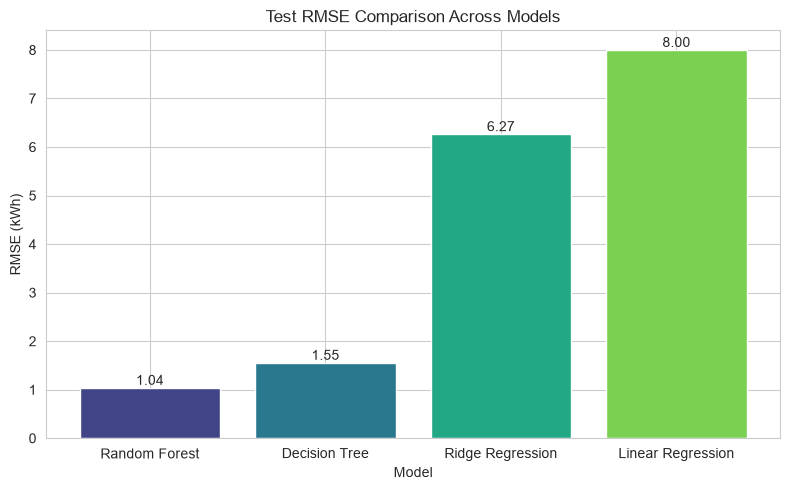

In [10]:
plt.figure(figsize=(8, 5))
order = results_df["RMSE"].sort_values().index
bars = plt.bar(order, results_df.loc[order, "RMSE"], color=sns.color_palette("viridis", len(order)))
plt.title("Test RMSE Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("RMSE (kWh)")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 10. Predicted vs Actual — Best Model

I pick the best model by lowest test RMSE and visualize how well its
predictions track the actual values.

Best model (lowest test RMSE): Random Forest


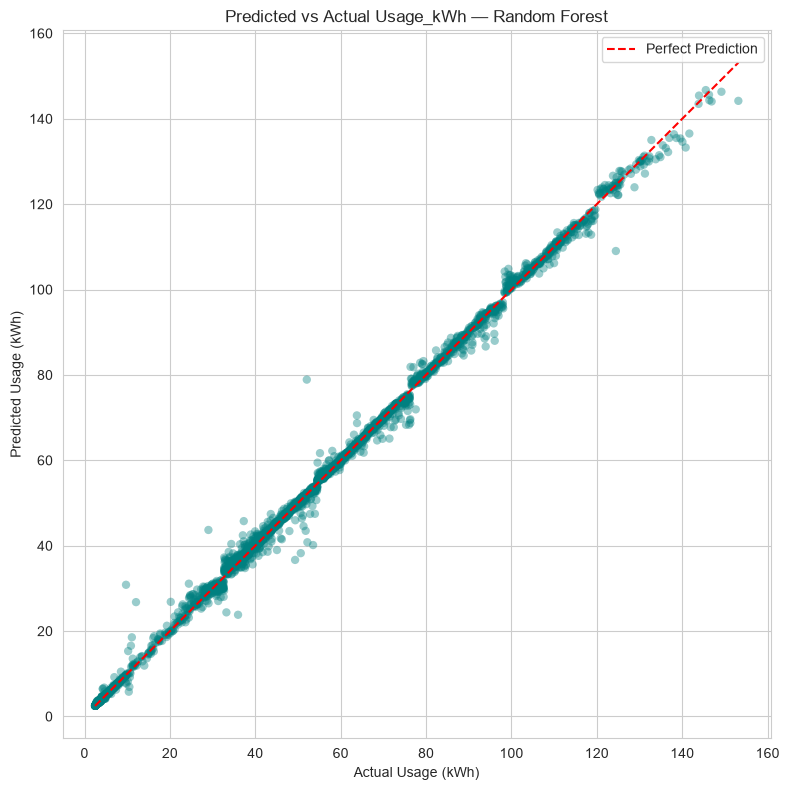

In [11]:
best_model_name = results_df["RMSE"].idxmin()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best model (lowest test RMSE): {best_model_name}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.4, color="teal", edgecolor="none")
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")
plt.title(f"Predicted vs Actual Usage_kWh — {best_model_name}")
plt.xlabel("Actual Usage (kWh)")
plt.ylabel("Predicted Usage (kWh)")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Model Selection

### Summary Table

| Model | Test MAE | Test RMSE | Test R² | CV Mean RMSE |
|---|---|---|---|---|
| Linear Regression | 5.616 | 8.001 | 0.9437 | 7.909 ± 0.082 |
| Ridge Regression | 4.360 | 6.267 | 0.9655 | 6.229 ± 0.092 |
| Decision Tree | 0.552 | 1.555 | 0.9979 | 1.421 ± 0.062 |
| Random Forest | 0.347 | 1.040 | 0.9990 | 1.010 ± 0.075 |

### Which model performed best

The **Random Forest Regressor** performed best, with the lowest test RMSE
(1.040 kWh), lowest test MAE (0.347 kWh), and highest test R² (0.9990),
and it also had the lowest 5-fold CV RMSE (1.010 ± 0.075). This is expected:
energy usage depends on non-linear interactions between load type,
time-of-day (`Hour`, `NSM`), and electrical readings (reactive power, power
factor) that a linear model cannot capture. Both linear models (Linear
Regression RMSE 8.001, Ridge RMSE 6.267) trail far behind the tree-based
models, confirming the relationship between the features and `Usage_kWh` is
substantially non-linear. Ridge's regularization gave it a meaningful edge
over plain Linear Regression (RMSE 6.267 vs. 8.001), suggesting some
multicollinearity among the electrical readings that L2 regularization helps
control.

### Signs of overfitting

- The **Decision Tree** shows the clearest overfitting signature: test RMSE
  (1.555) is noticeably higher than its 5-fold CV RMSE (1.421), and R² is
  already at 0.9979 on test — an unconstrained tree fits training data almost
  perfectly, so its test-time error is more sensitive to the specific
  train/test split than the ensemble's.
- The **Random Forest** shows almost no gap between test RMSE (1.040) and CV
  RMSE (1.010) — averaging across 200 trees smooths out the variance that a
  single tree suffers from, so it generalizes the most consistently of all
  four models.
- **Linear Regression** and **Ridge** show test RMSE very close to their CV
  RMSE (8.001 vs 7.909, and 6.267 vs 6.229), meaning low variance — but their
  absolute error is much higher than the tree-based models (high bias), i.e.
  they underfit the non-linear structure in the data rather than overfit.
- Overall: no model shows a large CV-vs-test RMSE gap, so the 80/20 split
  (`random_state=42`) looks representative; the main story here is bias
  (linear models) vs. a well-controlled bias-variance trade-off (Random
  Forest) rather than severe overfitting anywhere.

### Model carried forward

**Random Forest Regressor** is carried forward as the baseline model for
future weeks — it has the lowest error on both the held-out test set and
5-fold cross-validation, with the smallest train/test generalization gap of
the four models, all without any hyperparameter tuning yet. Hyperparameter
tuning (e.g. `max_depth`, `n_estimators`, `min_samples_leaf`) and feature
importance analysis are natural next steps to further improve and interpret
this baseline.
